# 4.3.2 Statistik Deskriptif Dataset

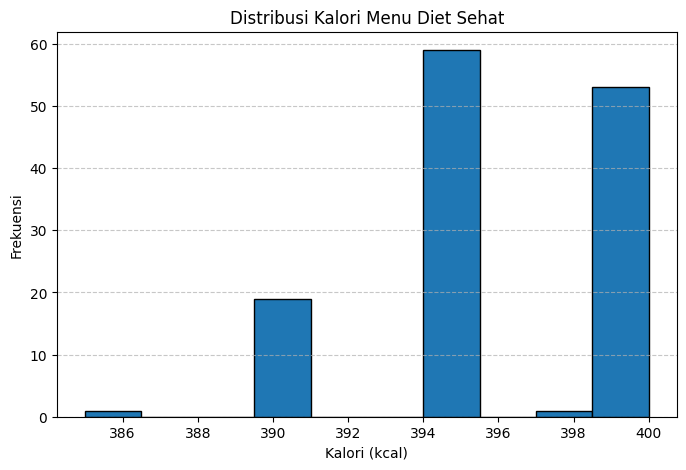

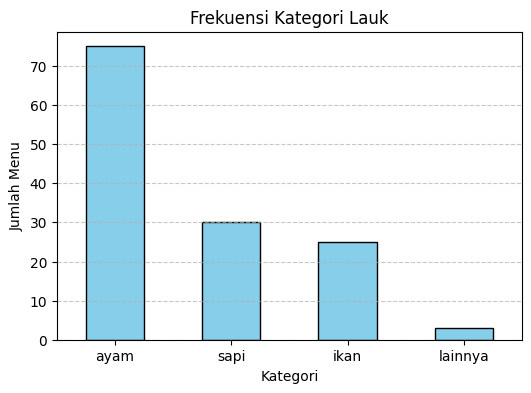

<Figure size 700x400 with 0 Axes>

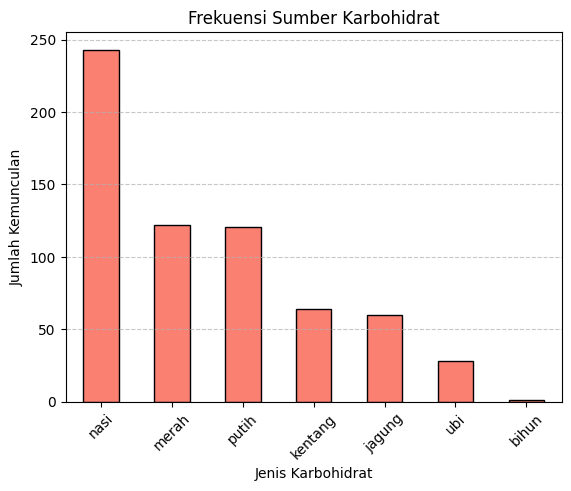

=== Statistik Deskriptif Kalori ===
count    133.000000
mean     396.218045
std        3.595743
min      385.000000
25%      395.000000
50%      395.000000
75%      400.000000
max      400.000000
Name: Kalori (kcal), dtype: float64

=== Proporsi Kategori Lauk (%) ===
Kategori
ayam       56.39
sapi       22.56
ikan       18.80
lainnya     2.26
Name: count, dtype: float64

=== Proporsi Sumber Karbohidrat (%) ===
{'jagung': 9.39, 'nasi': 38.03, 'merah': 19.09, 'putih': 18.94, 'kentang': 10.02, 'ubi': 4.38, 'bihun': 0.16}


In [ ]:
# --- VISUALISASI STATISTIK DESKRIPTIF DATASET ---

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Baca dataset bersih
df = pd.read_csv('/content/drive/MyDrive/MCCBF/Preprocessing/data_preprocessed_133.csv')

# ===============================
# GRAFIK 1 – DISTRIBUSI KALORI
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df['Kalori (kcal)'], bins=10, edgecolor='black')
plt.title('Distribusi Kalori Menu Diet Sehat')
plt.xlabel('Kalori (kcal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ===============================
# GRAFIK 2 – FREKUENSI KATEGORI LAUK
# ===============================
plt.figure(figsize=(6,4))
kategori_counts = df['Kategori'].value_counts()
kategori_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frekuensi Kategori Lauk')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Menu')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ===============================
# GRAFIK 3 – FREKUENSI SUMBER KARBOHIDRAT
# ===============================
karbo_list = df['Sumber Karbohidrat'].dropna().tolist()
all_karbo = []

for item in karbo_list:
    # Pisahkan berdasarkan spasi atau koma
    parts = item.replace(',', ' ').split()
    for k in parts:
        if k.strip() != '':
            all_karbo.append(k.strip().lower())

karbo_freq = Counter(all_karbo)
karbo_df = pd.DataFrame.from_dict(karbo_freq, orient='index', columns=['Frekuensi']).sort_values(by='Frekuensi', ascending=False)

plt.figure(figsize=(7,4))
karbo_df.plot(kind='bar', legend=False, color='salmon', edgecolor='black')
plt.title('Frekuensi Sumber Karbohidrat')
plt.xlabel('Jenis Karbohidrat')
plt.ylabel('Jumlah Kemunculan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ===============================
# RINGKASAN DESKRIPTIF
# ===============================
print("=== Statistik Deskriptif Kalori ===")
print(df['Kalori (kcal)'].describe())

print("\n=== Proporsi Kategori Lauk (%) ===")
print(round((kategori_counts / len(df)) * 100, 2))

print("\n=== Proporsi Sumber Karbohidrat (%) ===")
total_karbo = sum(karbo_freq.values())
karbo_percent = {k: round(v / total_karbo * 100, 2) for k, v in karbo_freq.items()}
print(karbo_percent)


# **🧩 Bagian 1 – Preprocessing Dataset**

🔹 1️⃣ Load Dataset

In [25]:
import pandas as pd

file_path = '/Users/enb/Documents/TA/sistemrekomendasi/data/dataset_mentah.csv'
df = pd.read_csv(file_path)
print(f"Jumlah data: {len(df)}")
df.head()

Jumlah data: 133


,No,Nama Menu,Kategori,Kalori (kcal),Sumber Karbohidrat,Bahan Utama / Pendamping,Deskripsi Singkat
0,1,Dori Cabe Garam,Ikan,395,"Jagung, Nasi Merah, Nasi Putih","Tumis Sayur, Snack","Ikan dori tumis, rasa pedas gurih, rendah minyak"
1,2,Sempol Ayam Grill,Ayam,395,"Kentang, Ubi, Nasi Merah, Nasi Putih","Steamed Vege, Snack","Ayam olahan panggang, tinggi protein, snack sehat"
2,3,Soto Ayam Spesial,Ayam,400,"Kentang, Nasi Merah, Nasi Putih","Steamed Vege, Sunny Egg","Soto ayam kuah bening, tanpa santan, lauk lengkap"
3,4,Beef Yakiniku,Sapi,395,"Jagung, Nasi Merah, Nasi Putih","Steamed Vege, Tofu","Daging sapi yakiniku, tumis sayur, saus gurih"
4,5,Rawon Surabaya,Sapi,400,"Kentang, Nasi Merah, Nasi Putih","Boiled Egg, Tempe","Daging rawon empuk, kuah rempah, lauk tempe"


🟢 Point 1 — Import Library

In [26]:
# ============================================================
# POINT 1: IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

print("✅ Library berhasil diimport.")


✅ Library berhasil diimport.


🟢 Point 2 — Load Dataset

In [29]:
# ============================================================
# POINT 2: LOAD DATASET
# ============================================================

# Ganti path sesuai lokasi file kamu
file_path = '/Users/enb/Documents/TA/sistemrekomendasi/data/dataset_mentah.csv'

df = pd.read_csv(file_path)
print("Dataset berhasil dimuat ✅")
print(f"Jumlah data: {len(df)}")
df.head()

Dataset berhasil dimuat ✅
Jumlah data: 133


,No,Nama Menu,Kategori,Kalori (kcal),Sumber Karbohidrat,Bahan Utama / Pendamping,Deskripsi Singkat
0,1,Dori Cabe Garam,Ikan,395,"Jagung, Nasi Merah, Nasi Putih","Tumis Sayur, Snack","Ikan dori tumis, rasa pedas gurih, rendah minyak"
1,2,Sempol Ayam Grill,Ayam,395,"Kentang, Ubi, Nasi Merah, Nasi Putih","Steamed Vege, Snack","Ayam olahan panggang, tinggi protein, snack sehat"
2,3,Soto Ayam Spesial,Ayam,400,"Kentang, Nasi Merah, Nasi Putih","Steamed Vege, Sunny Egg","Soto ayam kuah bening, tanpa santan, lauk lengkap"
3,4,Beef Yakiniku,Sapi,395,"Jagung, Nasi Merah, Nasi Putih","Steamed Vege, Tofu","Daging sapi yakiniku, tumis sayur, saus gurih"
4,5,Rawon Surabaya,Sapi,400,"Kentang, Nasi Merah, Nasi Putih","Boiled Egg, Tempe","Daging rawon empuk, kuah rempah, lauk tempe"


🟢 Point 3 — Cek Duplikat dan Missing Value

In [30]:
# ============================================================
# POINT 3: CEK DUPLIKAT & MISSING VALUE
# ============================================================

df.drop_duplicates(inplace=True)
print(f"Jumlah data setelah hapus duplikat: {len(df)}")

print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

# Isi nilai kosong dengan string kosong
df.fillna('', inplace=True)
print("\n✅ Missing value telah ditangani.")

Jumlah data setelah hapus duplikat: 133

Jumlah missing value per kolom:
No                          0
Nama Menu                   0
Kategori                    0
Kalori (kcal)               0
Sumber Karbohidrat          9
Bahan Utama / Pendamping    0
Deskripsi Singkat           0
dtype: int64

✅ Missing value telah ditangani.


🟢 Point 4 — Normalisasi Kolom Kalori

In [31]:
# ============================================================
# POINT 4: NORMALISASI KALORI
# ============================================================

if 'Kalori (kcal)' in df.columns:
    scaler = MinMaxScaler()
    df['kalori_normalized'] = scaler.fit_transform(df[['Kalori (kcal)']])
    print("✅ Kolom 'Kalori (kcal)' berhasil dinormalisasi (0–1).")
else:
    raise KeyError("Kolom 'Kalori (kcal)' tidak ditemukan di dataset!")

df[['Nama Menu', 'Kalori (kcal)', 'kalori_normalized']].head()

✅ Kolom 'Kalori (kcal)' berhasil dinormalisasi (0–1).


,Nama Menu,Kalori (kcal),kalori_normalized
0,Dori Cabe Garam,395,0.666667
1,Sempol Ayam Grill,395,0.666667
2,Soto Ayam Spesial,400,1.000000
3,Beef Yakiniku,395,0.666667
4,Rawon Surabaya,400,1.000000


🟢 Point 5 — Cleaning Teks dan Membuat Corpus

In [32]:
# ============================================================
# POINT 5: PEMBERSIHAN TEKS & PEMBUATAN CORPUS
# ============================================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

text_cols = ['Nama Menu', 'Kategori', 'Sumber Karbohidrat',
             'Bahan Utama / Pendamping', 'Deskripsi Singkat']

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(clean_text)
    else:
        print(f"⚠️ Kolom '{col}' tidak ditemukan, dilewati.")

df['corpus'] = df[text_cols].apply(lambda x: ' '.join(x), axis=1)

print("✅ Cleaning teks dan corpus selesai.")
df[['Nama Menu', 'corpus']].head()

✅ Cleaning teks dan corpus selesai.


,Nama Menu,corpus
0,dori cabe garam,dori cabe garam ikan jagung nasi merah nasi pu...
1,sempol ayam grill,sempol ayam grill ayam kentang ubi nasi merah ...
2,soto ayam spesial,soto ayam spesial ayam kentang nasi merah nasi...
3,beef yakiniku,beef yakiniku sapi jagung nasi merah nasi puti...
4,rawon surabaya,rawon surabaya sapi kentang nasi merah nasi pu...


🟢 Point 6 — TF-IDF Vectorizer

In [33]:
# ============================================================
# POINT 6: TF-IDF VECTORISASI
# ============================================================

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print(f"✅ TF-IDF selesai dibuat. Bentuk matriks: {tfidf_matrix.shape}")


✅ TF-IDF selesai dibuat. Bentuk matriks: (133, 500)


🟢 Point 7 — Split Train dan Test

In [34]:
# ============================================================
# POINT 7: SPLIT DATA TRAIN & TEST
# ============================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Kategori'],
    random_state=42
)

print(f"✅ Data berhasil dibagi:")
print(f"   • Train: {len(df_train)} data")
print(f"   • Test : {len(df_test)} data")


✅ Data berhasil dibagi:
   • Train: 106 data
   • Test : 27 data


🟢 Point 8 — Simpan File Hasil Preprocessing

In [35]:
# ============================================================
# POINT 8: SIMPAN FILE HASIL PREPROCESSING
# ============================================================

output_dir = '/Users/enb/Documents/TA/sistemrekomendasi/data/Preprocessing'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, 'data_preprocessed.csv'), index=False)
df_train.to_csv(os.path.join(output_dir, 'data_train.csv'), index=False)
df_test.to_csv(os.path.join(output_dir, 'data_test.csv'), index=False)

print("✅ File berhasil disimpan di folder Preprocessing:")
print("   - data_preprocessed.csv")
print("   - data_train.csv")
print("   - data_test.csv")

✅ File berhasil disimpan di folder Preprocessing:
   - data_preprocessed.csv
   - data_train.csv
   - data_test.csv


🟢 Point 10 — Import Library & Load Data Preprocessed

In [36]:
# ============================================================
# POINT 10: IMPORT LIBRARY & LOAD DATA PREPROCESSED
# ============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Path hasil preprocessing
train_path = 'data/Preprocessing/data_train.csv'
test_path = 'data/Preprocessing/data_test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"✅ Data berhasil dimuat: Train = {len(df_train)}, Test = {len(df_test)}")
df_train.head(2)

✅ Data berhasil dimuat: Train = 106, Test = 27


,No,Nama Menu,Kategori,Kalori (kcal),Sumber Karbohidrat,Bahan Utama / Pendamping,Deskripsi Singkat,kalori_normalized,corpus
0,80,ayam bakar padang,ayam,395,kentang ubi nasi merah nasi putih,steamed vege tempe,ayam bakar bumbu padang tanpa santan lauk tempe,0.666667,ayam bakar padang ayam kentang ubi nasi merah ...
1,49,ayam serundeng,ayam,395,jagung nasi merah nasi putih,tumis sayur snack,ayam tabur serundeng kelapa gurih tumis sayur,0.666667,ayam serundeng ayam jagung nasi merah nasi put...


🟢 Point 11 — TF-IDF Vectorizer (Hanya Fit ke Data Train)

In [37]:
# ============================================================
# POINT 11: TF-IDF VECTORISASI (FIT HANYA KE DATA TRAIN)
# ============================================================

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
tfidf_train = vectorizer.fit_transform(df_train['corpus'])
tfidf_test = vectorizer.transform(df_test['corpus'])

print(f"✅ TF-IDF selesai. Train shape: {tfidf_train.shape}, Test shape: {tfidf_test.shape}")

✅ TF-IDF selesai. Train shape: (106, 500), Test shape: (27, 500)


🟢 Point 12 — Definisi Fungsi Similarity Tiap Kriteria

In [38]:
# ============================================================
# POINT 12: DEFINISI SIMILARITY PER KRITERIA
# ============================================================

def categorical_similarity(a, b):
    """Rule-based similarity untuk kategori atau sumber karbohidrat"""
    a, b = str(a).lower(), str(b).lower()
    if a == b:
        return 1
    if any(word in b for word in a.split()):
        return 0.5
    return 0

print("✅ Fungsi similarity kategori dan karbohidrat siap digunakan.")

✅ Fungsi similarity kategori dan karbohidrat siap digunakan.


🟢 Point 13 — Hitung Similarity Antar Kriteria

In [39]:
# ============================================================
# POINT 13: HITUNG SIMILARITY UNTUK SETIAP KRITERIA (FIXED)
# ============================================================

print(">>> Menghitung similarity deskripsi (TF-IDF)...")
sim_deskripsi = cosine_similarity(tfidf_test, tfidf_train)

# --- Rename kolom agar bisa diakses tanpa error ---
df_train.rename(columns={'Sumber Karbohidrat': 'Sumber_Karbohidrat'}, inplace=True)
df_test.rename(columns={'Sumber Karbohidrat': 'Sumber_Karbohidrat'}, inplace=True)

print(">>> Menghitung similarity kategori dan sumber karbohidrat...")
sim_kategori = np.zeros((len(df_test), len(df_train)))
sim_karbo = np.zeros((len(df_test), len(df_train)))

for i, test_row in enumerate(df_test.itertuples()):
    for j, train_row in enumerate(df_train.itertuples()):
        sim_kategori[i, j] = categorical_similarity(test_row.Kategori, train_row.Kategori)
        sim_karbo[i, j] = categorical_similarity(test_row.Sumber_Karbohidrat, train_row.Sumber_Karbohidrat)

print(">>> Menghitung similarity kalori (numerik)...")
sim_kalori = 1 - np.abs(
    np.array(df_test['kalori_normalized']).reshape(-1, 1)
    - np.array(df_train['kalori_normalized']).reshape(1, -1)
)

print("✅ Semua similarity berhasil dihitung tanpa error.")


>>> Menghitung similarity deskripsi (TF-IDF)...
>>> Menghitung similarity kategori dan sumber karbohidrat...
>>> Menghitung similarity kalori (numerik)...
✅ Semua similarity berhasil dihitung tanpa error.


🟢 Point 14 — Pembobotan Multi-Kriteria

In [40]:
# ============================================================
# POINT 14: PEMBOBOTAN KRITERIA MCCBF
# ============================================================

# Skenario bobot
weights_default = {'deskripsi': 0.4, 'kategori': 0.2, 'karbohidrat': 0.2, 'kalori': 0.2}
weights_focus_cal = {'deskripsi': 0.25, 'kategori': 0.15, 'karbohidrat': 0.1, 'kalori': 0.5}

def compute_weighted_similarity(weights):
    return (
        weights['deskripsi'] * sim_deskripsi +
        weights['kategori'] * sim_kategori +
        weights['karbohidrat'] * sim_karbo +
        weights['kalori'] * sim_kalori
    )

# Buat dua varian MCCBF
sim_mccbf_default = compute_weighted_similarity(weights_default)
sim_mccbf_focus = compute_weighted_similarity(weights_focus_cal)

print("✅ Similarity gabungan MCCBF (dua skenario) selesai dihitung.")


✅ Similarity gabungan MCCBF (dua skenario) selesai dihitung.


🟢 Point 15 — Fungsi Rekomendasi Top-N

In [41]:
# ============================================================
# FIX untuk POINT 15: pastikan nama kolom konsisten & fungsi aman
# ============================================================

# 1) Normalisasi semua nama kolom: ubah spasi jadi underscore (sekali saja)
df_train.columns = df_train.columns.str.strip().str.replace(' ', '_')
df_test.columns  = df_test.columns.str.strip().str.replace(' ', '_')

# 2) Fungsi helper: ambil kolom yang ada (fallback jika nama berbeda)
def safe_select_columns(df, cols):
    """Kembalikan list kolom yang ada di df dari daftar 'cols' (urutannya dipertahankan)."""
    present = [c for c in cols if c in df.columns]
    return present

# 3) Perbarui fungsi rekomendasi jadi lebih robust
def get_top_recommendations(index_test, sim_matrix, top_n=5, df_train_local=None):
    if df_train_local is None:
        df_train_local = df_train
    sim_scores = sim_matrix[index_test]
    top_indices = sim_scores.argsort()[::-1][:top_n]
    # kolom kandidat yang ingin ditampilkan (gunakan nama dengan underscore)
    desired_cols = ['Nama_Menu', 'Kategori', 'Kalori_(kcal)', 'Sumber_Karbohidrat']
    # juga dukung versi tanpa underscore (fallback)
    alt_cols = ['Nama Menu', 'Kalori (kcal)', 'Sumber Karbohidrat']
    cols_to_use = safe_select_columns(df_train_local, desired_cols)
    if not cols_to_use:
        cols_to_use = safe_select_columns(df_train_local, alt_cols)
    # jika masih kosong, tampilkan semua kolom
    if not cols_to_use:
        cols_to_use = df_train_local.columns.tolist()

    rekom = df_train_local.iloc[top_indices][cols_to_use].copy()
    rekom['Skor_Similarity'] = sim_scores[top_indices]
    return rekom

# 4) Coba ulang contoh rekomendasi
sample_idx = 0  # pastikan index ini < len(df_test)
menu_uji = df_test.iloc[sample_idx]['Nama_Menu'] if 'Nama_Menu' in df_test.columns else df_test.iloc[sample_idx]['Nama Menu']
print(f"Rekomendasi untuk menu uji: {str(menu_uji).upper()}\n")

top5 = get_top_recommendations(sample_idx, sim_mccbf_default, top_n=5)
print(top5)


Rekomendasi untuk menu uji: CHICKEN WOKU

            Nama_Menu Kategori  Kalori_(kcal)             Sumber_Karbohidrat  \
47     ayam serundeng     ayam            400  kentang nasi merah nasi putih   
12  chicken ball woku     ayam            390  kentang nasi merah nasi putih   
70      chicken curry     ayam            400  kentang nasi merah nasi putih   
19      ayam maranggi     ayam            400  kentang nasi merah nasi putih   
58    ayam bumbu kari     ayam            400  kentang nasi merah nasi putih   

    Skor_Similarity  
47         0.758083  
12         0.754541  
70         0.737188  
19         0.710854  
58         0.699349  


🟢 Point 16 — Evaluasi Precision@5, Recall@5, F1-Score@5

In [42]:
# ============================================================
# POINT 16: EVALUASI MODEL MCCBF
# ============================================================

def evaluate(sim_matrix, df_test, df_train, top_n=5):
    precision_list, recall_list, f1_list = [], [], []

    for i, test_row in enumerate(df_test.itertuples()):
        sim_scores = sim_matrix[i]
        top_indices = sim_scores.argsort()[::-1][:top_n]
        top_cats = df_train.iloc[top_indices]['Kategori'].values
        true_cat = test_row.Kategori

        relevant = sum(1 for c in top_cats if c == true_cat)
        total_true = sum(df_train['Kategori'] == true_cat)

        precision = relevant / top_n
        recall = relevant / total_true if total_true > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return {
        'Precision@5': np.mean(precision_list),
        'Recall@5': np.mean(recall_list),
        'F1-Score@5': np.mean(f1_list)
    }

# Evaluasi untuk 3 model
eval_cbf = evaluate(sim_deskripsi, df_test, df_train)
eval_mccbf_default = evaluate(sim_mccbf_default, df_test, df_train)
eval_mccbf_focus = evaluate(sim_mccbf_focus, df_test, df_train)

results = pd.DataFrame([
    ['CBF Konvensional (TF-IDF Only)', *eval_cbf.values()],
    ['MCCBF (Bobot Seimbang)', *eval_mccbf_default.values()],
    ['MCCBF (Fokus Kalori)', *eval_mccbf_focus.values()]
], columns=['Model', 'Precision@5', 'Recall@5', 'F1-Score@5'])

print("\n=== HASIL EVALUASI SISTEM REKOMENDASI ===")
print(results.to_string(index=False))



=== HASIL EVALUASI SISTEM REKOMENDASI ===
                         Model  Precision@5  Recall@5  F1-Score@5
CBF Konvensional (TF-IDF Only)     0.777778  0.109259    0.186242
        MCCBF (Bobot Seimbang)     0.955556  0.154012    0.241237
          MCCBF (Fokus Kalori)     0.955556  0.154012    0.241237


🟢 Point 17 — Simpan Hasil Evaluasi

In [43]:
# ============================================================
# POINT 17: SIMPAN HASIL EVALUASI
# ============================================================

output_dir = '/Users/enb/Documents/TA/sistemrekomendasi/model'
os.makedirs(output_dir, exist_ok=True)

results.to_csv(os.path.join(output_dir, 'evaluasi_model.csv'), index=False)
print(f"✅ Hasil evaluasi disimpan ke: {output_dir}/evaluasi_model1.csv")

✅ Hasil evaluasi disimpan ke: /Users/enb/Documents/TA/sistemrekomendasi/model/evaluasi_model1.csv


In [44]:
# ============================================================
# POINT 18: SIMPAN ARTEFAK MODEL UNTUK DEPLOYMENT STREAMLIT
# ============================================================

import joblib

# buat folder model/
model_dir = '/Users/enb/Documents/TA/sistemrekomendasi/model'
os.makedirs(model_dir, exist_ok=True)

# Simpan vectorizer TF-IDF yang sudah di-fit
joblib.dump(vectorizer, os.path.join(model_dir, 'vectorizer_tfidf.pkl'))

# Simpan scaler kalori (digunakan untuk normalisasi input pengguna)
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))

# (Opsional) Simpan dataset train untuk digunakan di aplikasi Streamlit
df_train.to_csv(os.path.join(model_dir, 'data_train.csv'), index=False)

print("✅ Artefak model berhasil disimpan di folder:")
print(f"   📂 {model_dir}")
print("   - vectorizer_tfidf.pkl")
print("   - scaler.pkl")
print("   - data_train.csv (opsional)")


✅ Artefak model berhasil disimpan di folder:
   📂 /Users/enb/Documents/TA/sistemrekomendasi/model
   - vectorizer_tfidf.pkl
   - scaler.pkl
   - data_train.csv (opsional)


In [46]:
# ============================================================
# POINT 19: K-FOLD CROSS VALIDATION (EVALUASI TAMBAHAN)
# ============================================================

from sklearn.model_selection import KFold
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("\n=== K-FOLD CROSS VALIDATION UNTUK MCCBF ===")

df_full = pd.read_csv('/Users/enb/Documents/TA/sistemrekomendasi/data/Preprocessing/data_preprocessed.csv')
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

precision_list, recall_list, f1_list = [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(df_full)):
    df_train = df_full.iloc[train_idx].reset_index(drop=True)
    df_test = df_full.iloc[test_idx].reset_index(drop=True)

    # TF-IDF fit-transform di train
    vectorizer = TfidfVectorizer(max_features=300)
    tfidf_train = vectorizer.fit_transform(df_train['corpus'])
    tfidf_test = vectorizer.transform(df_test['corpus'])
    sim_deskripsi = cosine_similarity(tfidf_test, tfidf_train)

    # kalori
    sim_kalori = 1 - np.abs(
        np.array(df_test['kalori_normalized']).reshape(-1, 1)
        - np.array(df_train['kalori_normalized']).reshape(1, -1)
    )

    # kategori dan karbohidrat
    def categorical_similarity(a, b):
        a, b = str(a).lower(), str(b).lower()
        if a == b:
            return 1
        if any(w in b for w in a.split()):
            return 0.5
        return 0

    df_train.columns = df_train.columns.str.replace(' ', '_')
    df_test.columns = df_test.columns.str.replace(' ', '_')
    sim_kategori = np.zeros((len(df_test), len(df_train)))
    sim_karbo = np.zeros((len(df_test), len(df_train)))

    for i, test_row in enumerate(df_test.itertuples()):
        for j, train_row in enumerate(df_train.itertuples()):
            sim_kategori[i, j] = categorical_similarity(test_row.Kategori, train_row.Kategori)
            sim_karbo[i, j] = categorical_similarity(
                getattr(test_row, 'Sumber_Karbohidrat', ''),
                getattr(train_row, 'Sumber_Karbohidrat', '')
            )

    # Bobot MCCBF (misal versi default)
    w = {'deskripsi': 0.4, 'kategori': 0.2, 'karbohidrat': 0.2, 'kalori': 0.2}
    sim_total = (
        w['deskripsi'] * sim_deskripsi +
        w['kategori'] * sim_kategori +
        w['karbohidrat'] * sim_karbo +
        w['kalori'] * sim_kalori
    )

    # Evaluasi per fold
    p_list, r_list, f_list = [], [], []
    for i, test_row in enumerate(df_test.itertuples()):
        sim_scores = sim_total[i]
        top_idx = sim_scores.argsort()[::-1][:5]
        top_cats = df_train.iloc[top_idx]['Kategori'].values
        true_cat = test_row.Kategori
        relevant = sum(1 for c in top_cats if c == true_cat)
        total_true = sum(df_train['Kategori'] == true_cat)
        precision = relevant / 5
        recall = relevant / total_true if total_true > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        p_list.append(precision)
        r_list.append(recall)
        f_list.append(f1)

    precision_list.append(np.mean(p_list))
    recall_list.append(np.mean(r_list))
    f1_list.append(np.mean(f_list))
    print(f"Fold {fold+1} selesai ✅ | F1: {np.mean(f_list):.3f}")

# hasil rata-rata semua fold
print("\n=== HASIL RATA-RATA K-FOLD (5x) ===")
print(f"Precision@5: {np.mean(precision_list):.3f} ± {np.std(precision_list):.3f}")
print(f"Recall@5:    {np.mean(recall_list):.3f} ± {np.std(recall_list):.3f}")
print(f"F1-Score@5:  {np.mean(f1_list):.3f} ± {np.std(f1_list):.3f}")



=== K-FOLD CROSS VALIDATION UNTUK MCCBF ===
Fold 1 selesai ✅ | F1: 0.231
Fold 2 selesai ✅ | F1: 0.247
Fold 3 selesai ✅ | F1: 0.284
Fold 4 selesai ✅ | F1: 0.276
Fold 5 selesai ✅ | F1: 0.211

=== HASIL RATA-RATA K-FOLD (5x) ===
Precision@5: 0.975 ± 0.018
Recall@5:    0.158 ± 0.027
F1-Score@5:  0.250 ± 0.027


Matplotlib is building the font cache; this may take a moment.


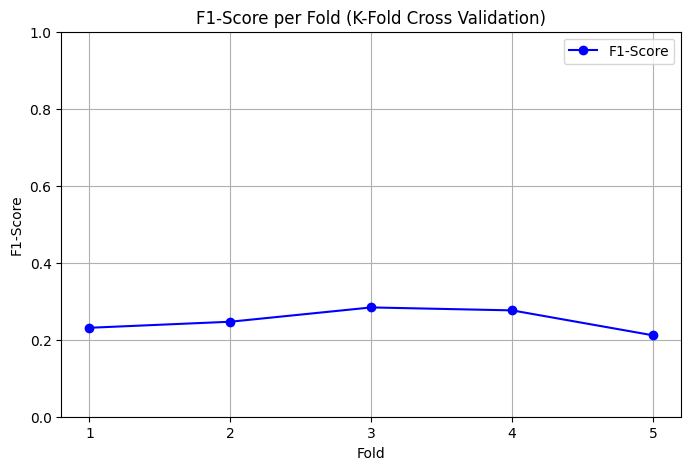

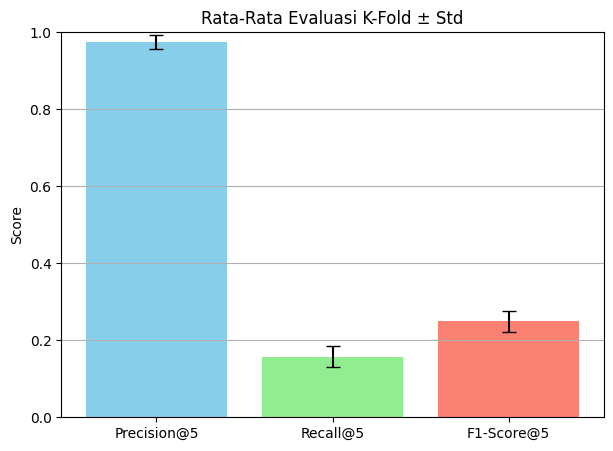

In [48]:
import matplotlib.pyplot as plt

folds = np.arange(1, K+1)

# --- Grafik F1 per fold ---
plt.figure(figsize=(8,5))
plt.plot(folds, f1_list, marker='o', linestyle='-', color='b', label='F1-Score')
plt.xticks(folds)
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.title('F1-Score per Fold (K-Fold Cross Validation)')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

# --- Bar chart rata-rata ± std ---
metrics = ['Precision@5', 'Recall@5', 'F1-Score@5']
means = [np.mean(precision_list), np.mean(recall_list), np.mean(f1_list)]
stds = [np.std(precision_list), np.std(recall_list), np.std(f1_list)]

plt.figure(figsize=(7,5))
plt.bar(metrics, means, yerr=stds, capsize=5, color=['skyblue','lightgreen','salmon'])
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Rata-Rata Evaluasi K-Fold ± Std')
plt.grid(axis='y')
plt.show()
